In [1]:
import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *
from syn_project.utils_notebook import *

%matplotlib widget

In [3]:
project_name = "syn"
condition = "basic"
data = "biased_00"
switch_epoch = 0
checkpoint_epoch = 0

n_samples_test = 1000
show_results_fusion = True
fusion_attr_weight = 1.0
noise = 0.0

experiment_name = get_experiment_name(condition, data, switch_epoch)
cat_names=CAT_NAMES

training_params = get_training_params(project_name, experiment_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

global_workspace = get_global_workspace(project_name, experiment_name, epoch=checkpoint_epoch)
data_module = get_data_module(project_name,  experiment_name)


Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/basic_biased_00/checkpoints/last.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/basic_biased_00/checkpoints/last.ckpt


/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [4]:
# 1. Paramètres initiaux
noise_params = {'std': 0.5, 'mean': 0.0}
n_iterations = 5

# 2. Préparation du premier échantillon (initialisation)
test_samples = get_data_samples(data_module, n_samples_test, noise=0.0, split="train")
# On initialise 'reshape' avec les attributs de départ
current_attr = test_samples[frozenset({'attr', 'v_latents'})]['attr']

# On utilise torch.no_grad() pour éviter l'accumulation du graphe de calcul (fuite mémoire)
with torch.no_grad():
    for i in range(n_iterations):
        # Préparation du dictionnaire pour l'encodage
        samples_dict = {frozenset({'attr', 'v_latents'}): {"attr": current_attr}}
        
        # Encodage
        unimodal_latents = global_workspace.encode_domains(samples_dict)
        gw_latents = global_workspace.encode(unimodal_latents)
        gw_latents_attr = gw_latents[frozenset({'attr', 'v_latents'})]['attr']

        # Ajout du bruit
        noise = torch.randn_like(gw_latents_attr) * noise_params['std'] + noise_params['mean']
        gw_latents_attr_noisy = gw_latents_attr + noise

        # Décodage vers image puis ré-encodage (boucle de reconstruction)
        decoded_image = global_workspace.decode({'attr': gw_latents_attr_noisy})['attr']['v_latents']
        
        # Encodage de l'image décodée
        # Attention à la structure des dictionnaires imbriqués propre à ton workspace
        img_input = {'v_latents': {'v_latents': decoded_image}}
        gw_latent_from_img = global_workspace.encode(img_input)['v_latents']['v_latents']

        # Fusion des deux représentations latentes
        fusion = 0.5 * gw_latents_attr_noisy + 0.5 * gw_latent_from_img

        # Décodage de la fusion vers les attributs
        decoded_attr_from_fusion = global_workspace.decode({'fusion': fusion})['fusion']['attr']

        # Transformation (logits -> probas + split)
        # On extrait ici le résultat pour l'itération suivante
        current_attr = split_softmax_category_attributes(decoded_attr_from_fusion)
        

<function matplotlib.pyplot.show(block=None)>

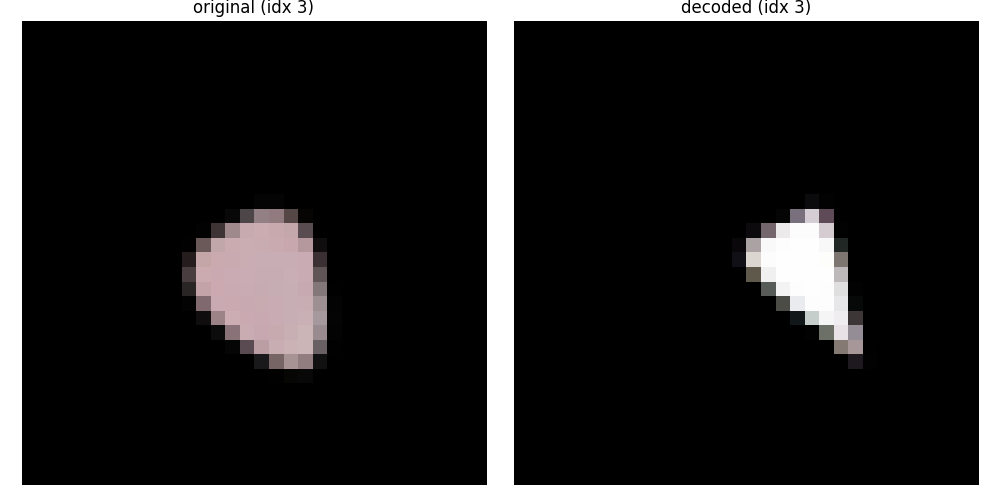

In [5]:
visual_module = cast(VisualLatentDomainModule, global_workspace.domain_mods["v_latents"])

decoded_images_rgb = visual_module.decode_images(decoded_image)
original_images = test_samples[frozenset({'attr', 'v_latents'})]['v_latents']
original_images_rgb = visual_module.decode_images(original_images)

import matplotlib.pyplot as plt


fig = plot_img_comparison(3, original_images_rgb, decoded_images_rgb)
plt.show



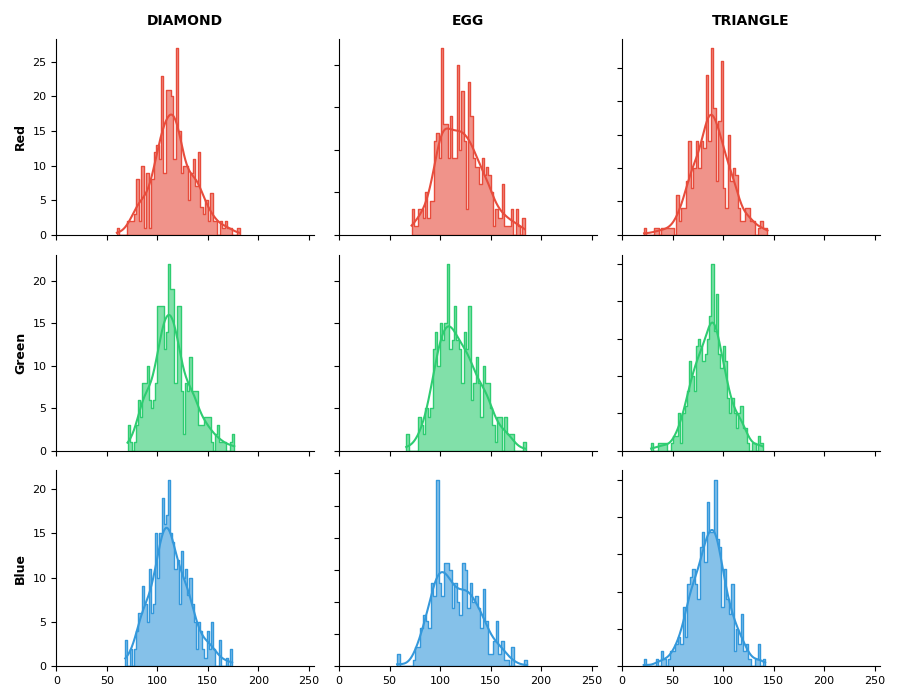

In [6]:
plot_type = "decoded_edge"
n_samples_test = 1000
data_translated = get_data_translated(global_workspace, test_samples, n_samples_test)

colors_np = get_samples_rgb(data_translated, plot_type)
categories_indices= get_categories_indices(data_translated)

fig = plot_rgb_distribution(colors_np, categories_indices, n_bins=50)
plt.show()
